In [4]:
import pandas as pd
import numpy as np
import cv2
import os
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pickle
import matplotlib.pyplot as plt
from pathlib import Path

In [9]:
df = pd.read_csv(r"C:\Users\Sairaj\OneDrive\Documents\banana_dataset.csv")
IMAGES_ROOT = r"C:\Users\Sairaj\OneDrive\Documents\Banana_dataset"

In [10]:
df.head()

,banana_id,day_number,days_remaining,split,file_path
0,1,1,7,train,"Banana Images Dataset\Banana1,1.jpeg"
1,2,1,7,train,"Banana Images Dataset\Banana2,1.jpeg"
2,3,1,7,train,"Banana Images Dataset\Banana3,1.jpeg"
3,4,1,7,train,"Banana Images Dataset\Banana4,1.jpeg"
4,5,1,7,train,"Banana Images Dataset\Banana5,1.jpeg"


In [11]:
df.sample(5)

,banana_id,day_number,days_remaining,split,file_path
10,11,1,7,test,"Banana Images Dataset\Banana11,1.jpeg"
89,6,8,0,train,"Banana Images Dataset\Banana6,8.jpeg"
51,4,5,3,train,"Banana Images Dataset\Banana4,5.jpeg"
47,12,4,4,test,"Banana Images Dataset\Banana12,4.jpeg"
21,10,2,6,test,"Banana Images Dataset\Banana10,2.jpeg"


In [12]:
df.shape

(96, 5)

In [13]:
df.dtypes

banana_id          int64
day_number         int64
days_remaining     int64
split             object
file_path         object
dtype: object

In [14]:
df['split'].value_counts()

split
train    72
test     24
Name: count, dtype: int64

In [ ]:
def extract_color_features(image):
    """
    Extract color-based features from image.
    Returns: list of 45 color features
    """
    features = []
    
    # Convert to HSV (better for banana ripeness detection)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # RGB channel statistics (15 features)
    for channel in range(3):
        channel_data = image[:, :, channel]
        features.extend([
            np.mean(channel_data),           # Mean
            np.std(channel_data),            # Standard deviation
            np.median(channel_data),         # Median
            np.percentile(channel_data, 25), # 25th percentile
            np.percentile(channel_data, 75), # 75th percentile
        ])
    
    # HSV channel statistics (6 features)
    for channel in range(3):
        channel_data = hsv[:, :, channel]
        features.extend([
            np.mean(channel_data),
            np.std(channel_data),
        ])
    
    # Dominant color (3 features)
    pixels = image.reshape(-1, 3)
    dominant = np.median(pixels, axis=0)
    features.extend(dominant)
    
    # Color histogram features (24 features - 8 bins per channel)
    for channel in range(3):
        hist = cv2.calcHist([image], [channel], None, [8], [0, 256])
        hist = hist.flatten() / hist.sum()  # Normalize
        features.extend(hist)
    
    return features


def extract_texture_features(image):
    """
    Extract texture-based features (spots, smoothness).
    Returns: list of 4 texture features
    """
    features = []
    
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Texture smoothness (1 feature)
    features.append(np.std(gray))
    
    # Edge detection - more edges = more spots (1 feature)
    edges = cv2.Canny(gray, 50, 150)
    edge_density = np.sum(edges > 0) / edges.size
    features.append(edge_density)
    
    # Laplacian variance - sharpness (1 feature)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    features.append(laplacian_var)
    
    # Brown spot detection (1 feature)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lower_brown = np.array([10, 50, 50])
    upper_brown = np.array([30, 200, 200])
    brown_mask = cv2.inRange(hsv, lower_brown, upper_brown)
    spot_coverage = np.sum(brown_mask > 0) / brown_mask.size
    features.append(spot_coverage)
    
    return features


def extract_shape_features(image):
    """
    Extract shape-based features.
    Returns: list of 4 shape features
    """
    features = []
    
    # Convert to grayscale and threshold
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
    
    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        # Get the largest contour (the banana)
        largest_contour = max(contours, key=cv2.contourArea)
        
        # Area
        area = cv2.contourArea(largest_contour)
        features.append(area)
        
        # Perimeter
        perimeter = cv2.arcLength(largest_contour, True)
        features.append(perimeter)
        
        # Aspect ratio
        x, y, w, h = cv2.boundingRect(largest_contour)
        aspect_ratio = float(w) / h if h > 0 else 0
        features.append(aspect_ratio)
        
        # Extent
        rect_area = w * h
        extent = float(area) / rect_area if rect_area > 0 else 0
        features.append(extent)
    else:
        # If no contours found, add zeros
        features.extend([0, 0, 0, 0])
    
    return features


def extract_all_features(image_path):
    """
    Extract ALL features from a banana image.
    Returns: numpy array of 53 features total
    """
    # Read image
    image = cv2.imread(str(image_path))
    
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")
    
    # Extract all features
    features = []
    features.extend(extract_color_features(image))      # 48 features
    features.extend(extract_texture_features(image))    # 4 features
    features.extend(extract_shape_features(image))      # 4 features
    
    return np.array(features)

Looking for image at: c:\Users\Sairaj\OneDrive\Desktop\Banana Project\Banana Images Dataset\Banana1,1.jpeg


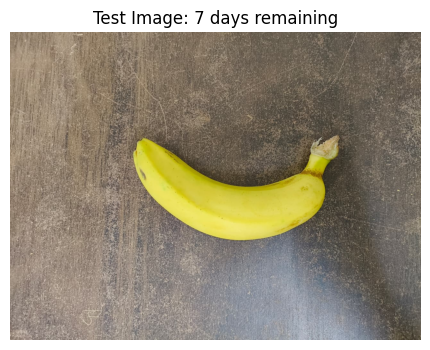

Success! Extracted 56 features.


In [22]:
IMAGES_ROOT = os.getcwd()

try:
    image_filename = df.iloc[0]['file_path'] 
    test_image_path = Path(IMAGES_ROOT) / image_filename

    print(f"Looking for image at: {test_image_path}")
    
    # --- VERIFICATION STEP ---
    # Before loading, let's explicitly check if the file is there
    if not test_image_path.exists():
        print(f"\n FILE NOT FOUND")
        print(os.listdir(IMAGES_ROOT))
        
        # If 'images' exists, check what is inside it
        if 'images' in os.listdir(IMAGES_ROOT):
            print("\nContents of 'images' folder:")
            print(os.listdir(os.path.join(IMAGES_ROOT, 'images'))[:5]) # Show first 5 files
        raise FileNotFoundError("Stopping execution because file is missing.")

    # Load and process
    test_image = cv2.imread(str(test_image_path))
    test_image_rgb = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(6, 4))
    plt.imshow(test_image_rgb)
    plt.title(f"Test Image: {df.iloc[0]['days_remaining']} days remaining")
    plt.axis('off')
    plt.show()
    
    # Extract features
    features = extract_all_features(str(test_image_path))
    print(f"Success! Extracted {len(features)} features.")

except Exception as e:
    print(f"\n Error Details: {e}")

In [17]:
def create_feature_dataset(df, images_root):
    """
    Extract features from all images in the dataset.
    """
    
    features_list = []
    labels_list = []
    splits_list = []
    valid_indices = []
    
    for idx, row in df.iterrows():
        try:
            # Construct full image path
            image_path = Path(images_root) / row['file_path']
            
            if not image_path.exists():
                print(f"Image not found: {image_path}")
                continue
            
            # Extract features
            features = extract_all_features(image_path)
            
            features_list.append(features)
            labels_list.append(row['days_remaining'])
            splits_list.append(row['split'])
            valid_indices.append(idx)
            
            # Progress update
            if (idx + 1) % 10 == 0:
                print(f"Processed {idx + 1}/{len(df)} images...")
        
        except Exception as e:
            print(f"Error processing {row['file_path']}: {e}")
    
    print(f"\n Successfully extracted features from {len(features_list)} images!")
    
    # Convert to numpy arrays
    x = np.array(features_list)
    y = np.array(labels_list)
    splits = np.array(splits_list)
    
    return x, y, splits

x, y, splits = create_feature_dataset(df, IMAGES_ROOT)

Processed 10/96 images...
Processed 20/96 images...
Processed 30/96 images...
Processed 40/96 images...
Processed 50/96 images...
Processed 60/96 images...
Processed 70/96 images...
Processed 80/96 images...
Processed 90/96 images...

 Successfully extracted features from 96 images!


In [11]:
x.shape

(96, 56)

In [12]:
y.shape

(96,)

In [30]:
train_mask = splits == 'train'
test_mask = splits == 'test'

x_train = x[train_mask]
x_test = x[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

In [31]:
len(x_train)

72

In [32]:
len(x_test)

24

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [43]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    verbose=0
)
gb_model.fit(x_train_scaled, y_train)

# Predictions
gb_train_pred = gb_model.predict(x_train_scaled)
gb_test_pred = gb_model.predict(x_test_scaled)

# Metrics
gb_train_mae = mean_absolute_error(y_train, gb_train_pred)
gb_test_mae = mean_absolute_error(y_test, gb_test_pred)
gb_test_rmse = np.sqrt(mean_squared_error(y_test, gb_test_pred))
gb_test_r2 = r2_score(y_test, gb_test_pred)

In [44]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
}

# Create base model
base_gb = GradientBoostingRegressor(random_state=42)

# Grid search
grid_search = GridSearchCV(
    base_gb,
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train_scaled, y_train)
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best CV MAE: {-grid_search.best_score_:.4f} days")

# Get tuned model
tuned_model = grid_search.best_estimator_

# Evaluate on test set
tuned_test_pred = tuned_model.predict(x_test_scaled)
tuned_test_mae = mean_absolute_error(y_test, tuned_test_pred)
tuned_test_r2 = r2_score(y_test, tuned_test_pred)

print(f"\nTuned Model Performance:")
print(f"  Test MAE: {tuned_test_mae:.4f} days")
print(f"  Test R²: {tuned_test_r2:.4f}")

# Use tuned model as final model
final_model = tuned_model
print("\n Using tuned model as final model!")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 200}
Best CV MAE: 2.2003 days

Tuned Model Performance:
  Test MAE: 0.1657 days
  Test R²: 0.9551

 Using tuned model as final model!


In [47]:
# Create model package
model_package = {
    'model': final_model,
    'scaler': scaler,
    'model_name': type(final_model).__name__,
    'test_mae': tuned_test_mae,
    'test_r2': tuned_test_r2,
    'training_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

# Save to file
model_filename = 'banana_expiry_predictor.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(model_package, f)

print(f"Model saved successfully to: {model_filename}")
print(f"\nModel Info:")
print(f"  Model Type: {model_package['model_name']}")
print(f"  Test MAE: {model_package['test_mae']:.4f} days")
print(f"  Test R²: {model_package['test_r2']:.4f}")
print(f"  Training Date: {model_package['training_date']}")

Model saved successfully to: banana_expiry_predictor.pkl

Model Info:
  Model Type: GradientBoostingRegressor
  Test MAE: 0.1657 days
  Test R²: 0.9551
  Training Date: 2026-01-18 13:23:33


In [48]:
def predict_banana_expiry(image_path, model_package):
    """
    Predict when a banana will expire from an uploaded image.
    
    Args:
        image_path: Path to the banana image
        model_package: The saved model package (loaded from pickle)
    
    Returns:
        dict with prediction results
    """
    try:
        # Extract features from the image
        features = extract_all_features(image_path)
        
        # Scale features
        features_scaled = model_package['scaler'].transform([features])
        
        # Make prediction
        days_remaining = model_package['model'].predict(features_scaled)[0]
        
        # Round to nearest 0.5 day
        days_remaining = round(days_remaining * 2) / 2
        
        # Ensure non-negative
        days_remaining = max(0, days_remaining)
        
        # Create result
        result = {
            'days_remaining': days_remaining,
            'expiry_date': (pd.Timestamp.now() + pd.Timedelta(days=days_remaining)).strftime('%Y-%m-%d'),
            'status': 'fresh' if days_remaining >= 5 else 'ripe' if days_remaining >= 2 else 'overripe',
            'confidence': 'High' if abs(days_remaining - round(days_remaining)) < 0.5 else 'Medium'
        }
        
        return result
    
    except Exception as e:
        return {'error': str(e)}


print(" Prediction function created!")
print("\nYou can now use: predict_banana_expiry(image_path, model_package)")

 Prediction function created!

You can now use: predict_banana_expiry(image_path, model_package)


In [50]:
# Get test indices
test_indices = np.where(splits == 'test')[0]
sample_indices = np.random.choice(test_indices, min(5, len(test_indices)), replace=False)

for idx in sample_indices:
    image_path = Path(IMAGES_ROOT) / df.iloc[idx]['file_path']
    actual_days = df.iloc[idx]['days_remaining']
    
    # Make prediction
    result = predict_banana_expiry(image_path, model_package)
    
    if 'error' not in result:
        print(f"Image: {df.iloc[idx]['file_path']}")
        print(f"  Actual days remaining: {actual_days}")
        print(f"  Predicted days remaining: {result['days_remaining']}")
        print(f"  Predicted expiry date: {result['expiry_date']}")
        print(f"  Status: {result['status']}")
        print(f"  Error: {abs(result['days_remaining'] - actual_days):.2f} days")
        print()
    else:
        print(f"Error processing image: {result['error']}\n")

Image: Banana Images Dataset\Banana11,3.jpeg
  Actual days remaining: 5
  Predicted days remaining: 5.0
  Predicted expiry date: 2026-01-23
  Status: fresh
  Error: 0.00 days

Image: Banana Images Dataset\Banana10,2.jpeg
  Actual days remaining: 6
  Predicted days remaining: 6.0
  Predicted expiry date: 2026-01-24
  Status: fresh
  Error: 0.00 days

Image: Banana Images Dataset\Banana10,1.jpeg
  Actual days remaining: 7
  Predicted days remaining: 7.0
  Predicted expiry date: 2026-01-25
  Status: fresh
  Error: 0.00 days

Image: Banana Images Dataset\Banana11,6.jpeg
  Actual days remaining: 2
  Predicted days remaining: 2.0
  Predicted expiry date: 2026-01-20
  Status: ripe
  Error: 0.00 days

Image: Banana Images Dataset\Banana10,5.jpeg
  Actual days remaining: 3
  Predicted days remaining: 2.0
  Predicted expiry date: 2026-01-20
  Status: ripe
  Error: 1.00 days



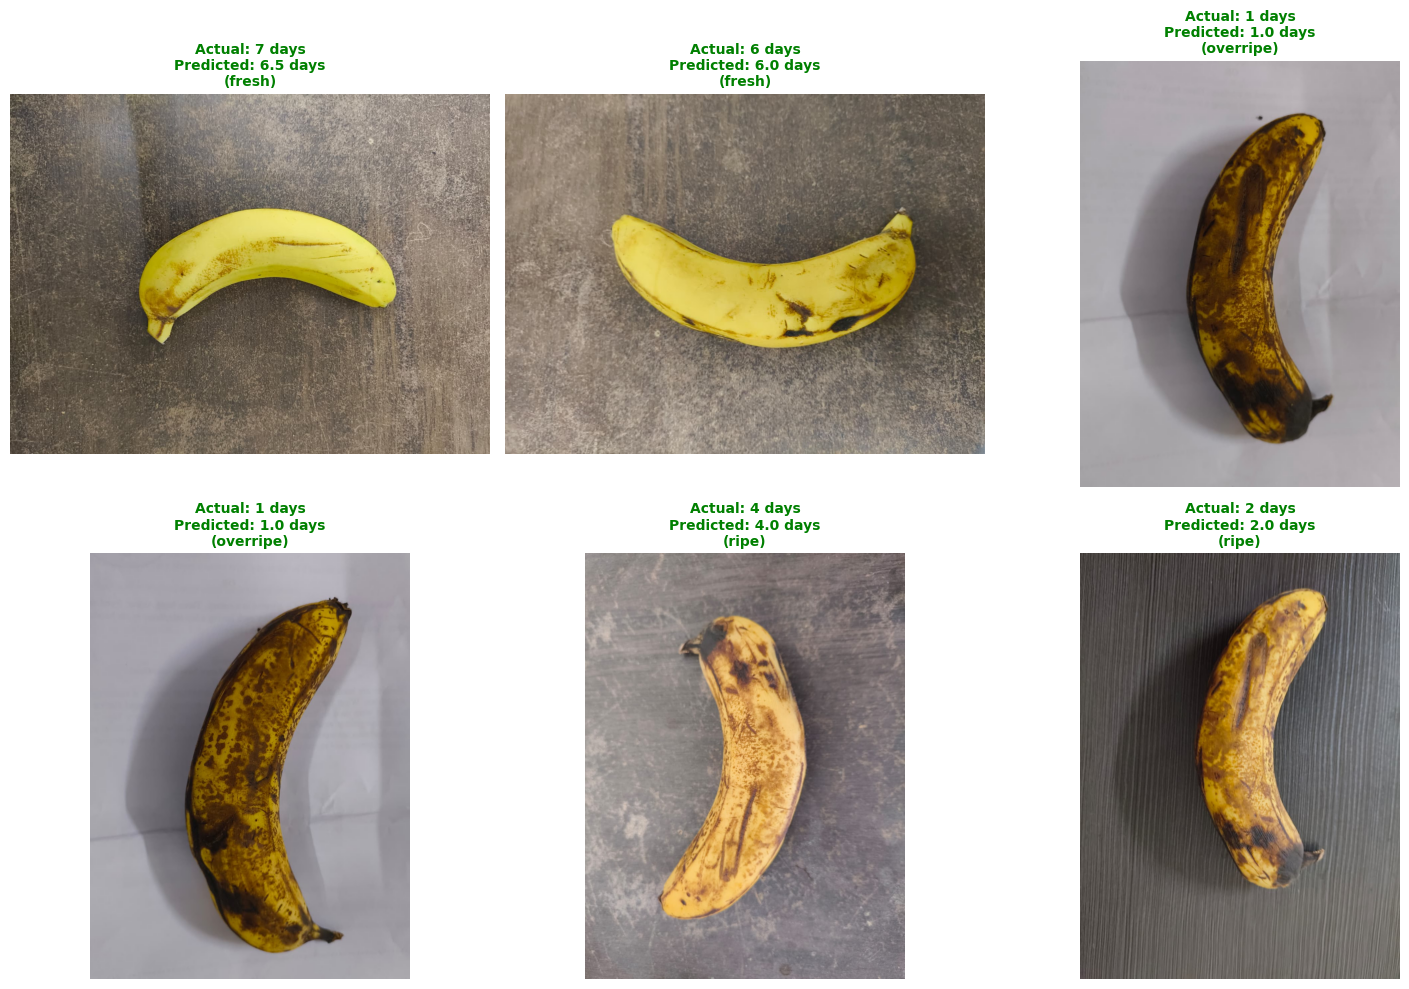

In [281]:
# Visualize predictions on test images
test_indices = np.where(splits == 'test')[0]
sample_indices = np.random.choice(test_indices, min(6, len(test_indices)), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    image_path = Path(IMAGES_ROOT) / df.iloc[idx]['file_path']
    actual_days = df.iloc[idx]['days_remaining']
    
    # Load image
    image = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Make prediction
    result = predict_banana_expiry(image_path, model_package)
    
    # Plot
    axes[i].imshow(image_rgb)
    axes[i].axis('off')
    
    if 'error' not in result:
        title = f"Actual: {actual_days} days\nPredicted: {result['days_remaining']} days\n({result['status']})"
        color = 'green' if abs(result['days_remaining'] - actual_days) < 1 else 'orange'
    else:
        title = "Error"
        color = 'red'
    
    axes[i].set_title(title, fontsize=10, color=color, weight='bold')

plt.tight_layout()
plt.show()